# Compute composites of Ipos and Ineg against JRA55 forcing

### imports

In [1]:
import sys
import os
from datetime import datetime

import numpy as np
import pandas as pd
import xarray as xr
import scipy as sci
import glob

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean.cm as cmo
from cmocean.tools import lighten

# Ensure we are in the correct directory
os.chdir("/home/581/pjb581/analysis_samw")
print(os.getcwd())

print("python version =",sys.version[:5])
print("numpy version =", np.__version__)
print("xarray version =", xr.__version__)
print("scipy version =", sci.__version__)
print("matplotlib version =", sys.modules[plt.__package__].__version__)
print("cmocean version =", sys.modules[cmo.__package__].__version__)
print("cartopy version =", sys.modules[ccrs.__package__].__version__)

print(datetime.now())

"""
NOTE: Need read permissions for group ia39
"""

/home/581/pjb581/analysis_samw
python version = 3.10.
numpy version = 2.2.5
xarray version = 2025.4.0
scipy version = 1.15.3
matplotlib version = 3.10.6
cmocean version = v3.0.3
cartopy version = 0.24.1
2026-09-17 13:43:22.400916


'\nNOTE: Need read permissions for group ia39\n'

In [3]:
import dask
from dask.distributed import Client, LocalCluster
cluster = LocalCluster(n_workers=14, threads_per_worker=2, memory_limit="32GB")
client  = Client(cluster)
client  # shows dashboard link



/g/data/es60/pjb581/miniforge3/envs/model_assessment_env/lib/python3.10/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 37863 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/37863/status,
Dashboard: /proxy/37863/status,Workers: 14
Total threads: 28,Total memory: 417.23 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35587,Workers: 0
Dashboard: /proxy/37863/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:42989,Total threads: 2
Dashboard: /proxy/39245/status,Memory: 29.80 GiB
Nanny: tcp://127.0.0.1:36289,


2026-09-17 18:58:02,907 - tornado.application - ERROR - Uncaught exception GET /individual-task-stream/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='gadi-cpu-bdw-0612.gadi.nci.org.au:58315', method='GET', uri='/individual-task-stream/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/g/data/es60/pjb581/miniforge3/envs/model_assessment_env/lib/python3.10/site-packages/tornado/websocket.py", line 965, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
  File "/g/data/es60/pjb581/miniforge3/envs/model_assessment_env/lib/python3.10/site-packages/tornado/web.py", line 3375, in wrapper
    return method(self, *args, **kwargs)
  File "/g/data/es60/pjb581/miniforge3/envs/model_assessment_env/lib/python3.10/site-packages/bokeh/server/views/ws.py", line 149, in open
    raise ProtocolError("Token is expired. Configure the app with a larger value for --session-token-expiration if necessary")
bokeh.prot

## Load I+ timeseries

CPU times: user 5.87 s, sys: 2.09 s, total: 7.96 s
Wall time: 11.7 s


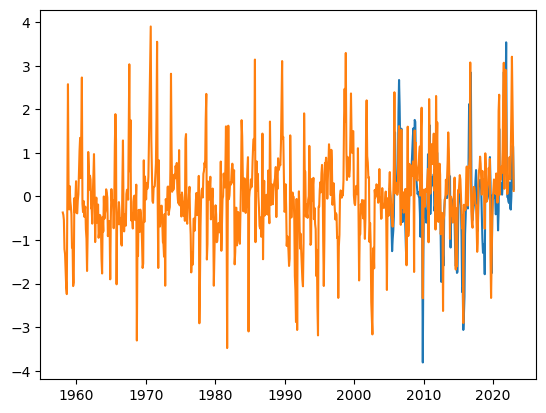

In [4]:
%%time

datapath = "/home/581/pjb581/analysis_samw"

Ipos_pac_EN4 = xr.open_dataset(datapath + "/Ipos_pac_EN4_2005-2022.nc").squeeze()
Ipos_ind_EN4 = xr.open_dataset(datapath + "/Ipos_ind_EN4_2005-2022.nc").squeeze()
Ineg_pac_EN4 = xr.open_dataset(datapath + "/Ineg_pac_EN4_2005-2022.nc").squeeze()
Ineg_ind_EN4 = xr.open_dataset(datapath + "/Ineg_ind_EN4_2005-2022.nc").squeeze()

Ipos_pac_sim = xr.open_dataset(datapath + "/Ipos_pac_1958-2022.nc").squeeze()
Ipos_ind_sim = xr.open_dataset(datapath + "/Ipos_ind_1958-2022.nc").squeeze()
Ineg_pac_sim = xr.open_dataset(datapath + "/Ineg_pac_1958-2022.nc").squeeze()
Ineg_ind_sim = xr.open_dataset(datapath + "/Ineg_ind_1958-2022.nc").squeeze()

Ipos_pac_EN4 = Ipos_pac_EN4["I_MLD"]
Ipos_ind_EN4 = Ipos_ind_EN4["I_MLD"]
Ineg_pac_EN4 = Ineg_pac_EN4["I_MLD"]
Ineg_ind_EN4 = Ineg_ind_EN4["I_MLD"]
Ipos_pac_sim = Ipos_pac_sim["I_MLD"]
Ipos_ind_sim = Ipos_ind_sim["I_MLD"]
Ineg_pac_sim = Ineg_pac_sim["I_MLD"]
Ineg_ind_sim = Ineg_ind_sim["I_MLD"]

plt.figure()
plt.plot(Ipos_pac_EN4.time, Ipos_pac_EN4)
plt.plot(Ipos_pac_sim.time, Ipos_pac_sim)


### get JRA55 data

In [ ]:
%%time

jra55_data = "/g/data/qv56/replicas/input4MIPs/CMIP6Plus/OMIP/MRI/MRI-JRA55-do-1-6-0/atmos"

prra = xr.open_mfdataset(jra55_data + "/3hr/prra/gr/v20240531/prra_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-6-0_gr_*01010130-*12312230.nc")['prra']
prsn = xr.open_mfdataset(jra55_data + "/3hr/prsn/gr/v20240531/prsn_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-6-0_gr_*01010130-*12312230.nc")['prsn']
rlds = xr.open_mfdataset(jra55_data + "/3hr/rlds/gr/v20240531/rlds_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-6-0_gr_*01010130-*12312230.nc")['rlds']
rsds = xr.open_mfdataset(jra55_data + "/3hr/rsds/gr/v20240531/rsds_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-6-0_gr_*01010130-*12312230.nc")['rsds']
huss = xr.open_mfdataset(jra55_data + "/3hrPt/huss/gr/v20240531/huss_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-6-0_gr_*01010000-*12312100.nc")['huss']
psl = xr.open_mfdataset(jra55_data + "/3hrPt/psl/gr/v20240531/psl_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-6-0_gr_*01010000-*12312100.nc")['psl']
tas = xr.open_mfdataset(jra55_data + "/3hrPt/tas/gr/v20240531/tas_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-6-0_gr_*01010000-*12312100.nc")['tas']
ts = xr.open_mfdataset(jra55_data + "/3hrPt/ts/gr/v20240531/ts_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-6-0_gr_*01010000-*12312100.nc")['ts']
uas = xr.open_mfdataset(jra55_data + "/3hrPt/uas/gr/v20240531/uas_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-6-0_gr_*01010000-*12312100.nc")['uas']
vas = xr.open_mfdataset(jra55_data + "/3hrPt/vas/gr/v20240531/vas_input4MIPs_atmosphericState_OMIP_MRI-JRA55-do-1-6-0_gr_*01010000-*12312100.nc")['vas']


### Place JRA55 and indices on the same times

In [6]:
import warnings
warnings.filterwarnings('ignore')

In [11]:
%%time

def reindex_time(dat, newtime):
    dat_month = dat.resample(time="1MS").mean()
    dat_month = dat_month.reindex(time=newtime, method='nearest').compute()
    return dat_month

prra_month = reindex_time(prra, Ipos_pac_sim.time)
print("Completed prra")
prsn_month = reindex_time(prsn, Ipos_pac_sim.time)
print("Completed prsn")
rlds_month = reindex_time(rlds, Ipos_pac_sim.time)
print("Completed rlds")
rsds_month = reindex_time(rsds, Ipos_pac_sim.time)
print("Completed rsds")
huss_month = reindex_time(huss, Ipos_pac_sim.time)
print("Completed huss")
psl_month = reindex_time(psl, Ipos_pac_sim.time)
print("Completed psl")
tas_month = reindex_time(tas, Ipos_pac_sim.time)
print("Completed tas")
uas_month = reindex_time(uas, Ipos_pac_sim.time)
print("Completed uas")
vas_month = reindex_time(vas, Ipos_pac_sim.time)
print("Completed vas")

vas_month

CPU times: user 1h 24min 33s, sys: 6min 10s, total: 1h 30min 43s
Wall time: 1h 31min 37s


<xarray.DataArray 'vas' (time: 780, lat: 320, lon: 640)> Size: 639MB
array([[[-2.3929117e+00, -2.4236517e+00, -2.4543920e+00, ...,
         -2.2901890e+00, -2.3244300e+00, -2.3586707e+00],
        [-2.3768940e+00, -2.4130630e+00, -2.4492321e+00, ...,
         -2.2613170e+00, -2.2998428e+00, -2.3383687e+00],
        [-2.4523005e+00, -2.4875233e+00, -2.5227454e+00, ...,
         -2.3346598e+00, -2.3738732e+00, -2.4130869e+00],
        ...,
        [-1.9458202e+00, -1.9243904e+00, -1.9029608e+00, ...,
         -1.9973246e+00, -1.9801563e+00, -1.9629884e+00],
        [-1.9437004e+00, -1.9227523e+00, -1.9018043e+00, ...,
         -2.0019305e+00, -1.9825203e+00, -1.9631104e+00],
        [-1.9424103e+00, -1.9188454e+00, -1.8952802e+00, ...,
         -2.0049212e+00, -1.9840844e+00, -1.9632472e+00]],

       [[-2.8393717e+00, -2.8860755e+00, -2.9327786e+00, ...,
         -2.6865938e+00, -2.7375197e+00, -2.7884462e+00],
        [-2.7763889e+00, -2.8348064e+00, -2.8932250e+00, ...,
         -2.5890360e+00, -2.6514871e+00, -2.7139380e+00],
        [-2.7634337e+00, -2.8242247e+00, -2.8850160e+00, ...,
         -2.5623465e+00, -2.6293752e+00, -2.6964042e+00],
...
          1.4952311e-01,  1.6582727e-01,  1.8213145e-01],
        [ 4.6462707e-02,  6.0529791e-02,  7.4596994e-02, ...,
          2.8285981e-04,  1.5676053e-02,  3.1069398e-02],
        [-2.8018545e-02, -1.8134387e-02, -8.2501415e-03, ...,
         -6.3049741e-02, -5.1372670e-02, -3.9695587e-02]],

       [[-3.4426825e+00, -3.4672034e+00, -3.4917247e+00, ...,
         -3.3535402e+00, -3.3832543e+00, -3.4129684e+00],
        [-3.3151691e+00, -3.3510327e+00, -3.3868966e+00, ...,
         -3.1961901e+00, -3.2358499e+00, -3.2755101e+00],
        [-3.3492255e+00, -3.3872905e+00, -3.4253545e+00, ...,
         -3.2212443e+00, -3.2639048e+00, -3.3065653e+00],
        ...,
        [-3.2656505e+00, -3.2595146e+00, -3.2533782e+00, ...,
         -3.2705266e+00, -3.2689011e+00, -3.2672758e+00],
        [-3.2535324e+00, -3.2455063e+00, -3.2374802e+00, ...,
         -3.2724514e+00, -3.2661450e+00, -3.2598386e+00],
        [-3.2240527e+00, -3.2133203e+00, -3.2025869e+00, ...,
         -3.2467396e+00, -3.2391770e+00, -3.2316151e+00]]],
      shape=(780, 320, 640), dtype=float32)
Coordinates:
  * lat      (lat) float64 3kB -89.57 -89.01 -88.45 -87.89 ... 88.45 89.01 89.57
  * lon      (lon) float64 5kB 0.0 0.5625 1.125 1.688 ... 358.3 358.9 359.4
  * time     (time) datetime64[ns] 6kB 1958-01-15 1958-02-15 ... 2022-12-15
    height   float64 8B 10.0
Attributes:
    standard_name:  northward_wind
    long_name:      Northward Near-Surface Wind
    comment:        Northward component of the near surface wind
    units:          m s-1
    cell_methods:   area: mean time: point
    cell_measures:  area: areacella
    history:        2024-05-31T12:00:50Z altered by CMOR: Treated scalar dime...

### Save the datasets

In [19]:
%%time
    
prra_month.to_netcdf("/g/data/vn19/pjb581/prra_monthly_1958-2022.nc")
prsn_month.to_netcdf("/g/data/vn19/pjb581/prsn_monthly_1958-2022.nc")
rlds_month.to_netcdf("/g/data/vn19/pjb581/rlds_monthly_1958-2022.nc")
rsds_month.to_netcdf("/g/data/vn19/pjb581/rsds_monthly_1958-2022.nc")
huss_month.to_netcdf("/g/data/vn19/pjb581/huss_monthly_1958-2022.nc")
psl_month.to_netcdf("/g/data/vn19/pjb581/psl_monthly_1958-2022.nc")
tas_month.to_netcdf("/g/data/vn19/pjb581/tas_monthly_1958-2022.nc")
uas_month.to_netcdf("/g/data/vn19/pjb581/uas_monthly_1958-2022.nc")
vas_month.to_netcdf("/g/data/vn19/pjb581/vas_monthly_1958-2022.nc")


CPU times: user 4.08 s, sys: 8.58 s, total: 12.7 s
Wall time: 11.4 s


### load the presaved datasets

In [5]:
%%time

prra_month = xr.open_dataarray("/g/data/vn19/pjb581/prra_monthly_1958-2022.nc")
prsn_month = xr.open_dataarray("/g/data/vn19/pjb581/prsn_monthly_1958-2022.nc")
rlds_month = xr.open_dataarray("/g/data/vn19/pjb581/rlds_monthly_1958-2022.nc")
rsds_month = xr.open_dataarray("/g/data/vn19/pjb581/rsds_monthly_1958-2022.nc")
huss_month = xr.open_dataarray("/g/data/vn19/pjb581/huss_monthly_1958-2022.nc")
psl_month = xr.open_dataarray("/g/data/vn19/pjb581/psl_monthly_1958-2022.nc")
tas_month = xr.open_dataarray("/g/data/vn19/pjb581/tas_monthly_1958-2022.nc")
uas_month = xr.open_dataarray("/g/data/vn19/pjb581/uas_monthly_1958-2022.nc")
vas_month = xr.open_dataarray("/g/data/vn19/pjb581/vas_monthly_1958-2022.nc")


CPU times: user 431 ms, sys: 175 ms, total: 607 ms
Wall time: 627 ms


### calculate wind speed

In [6]:
%%time

wnd_month = (uas_month**2 + vas_month**2)**0.5


CPU times: user 1.92 s, sys: 2.24 s, total: 4.17 s
Wall time: 2.91 s


### grab the actual model output of heat flux and wind stresses to take a look

In [7]:
%%time

mod = xr.open_dataset("/g/data/vn19/pjb581/JRA55_pic_1m_heatandwind_1958-2022.nc")

### group the month and year to one time coordinate
mod_month = (mod.stack(time=("record", "time_counter"))
    .reset_index("time", drop=True)
    .drop_vars("time_centered", errors="ignore")
    .assign_coords(time=Ipos_pac_sim.time.values)
)

qt = mod_month['qt']
qt_oce = mod_month['qt_oce']
wspd = mod_month['wspd']
taum = mod_month['taum']

taum

CPU times: user 1.01 s, sys: 696 ms, total: 1.71 s
Wall time: 1.39 s


<xarray.DataArray 'taum' (y: 149, x: 182, time: 780)> Size: 85MB
array([[[ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.]],

       [[ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        ...,
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.]],

       [[ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 0.,  0.,  0., ...,  0.,  0.,  0.],
        ...,
...
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(149, 182, 780), dtype=float32)
Coordinates:
    nav_lat  (y, x) float32 108kB ...
    nav_lon  (y, x) float32 108kB ...
  * time     (time) datetime64[ns] 6kB 1958-01-15 1958-02-15 ... 2022-12-15
Dimensions without coordinates: y, x
Attributes:
    standard_name:       magnitude_of_surface_downward_stress
    long_name:           wind stress module
    units:               N/m2
    online_operation:    average
    interval_operation:  10800 s
    interval_write:      1 month
    cell_methods:        time: mean (interval: 10800 s)
    cell_measures:       area: area

### linearly regress the I_MLD indices against the monthly mean JRA55-do conditions

In [10]:
%%time

from scipy.stats import linregress

def regress(y, x):
    mask = np.isfinite(y) & np.isfinite(x)
    if mask.sum() < 3:
        return np.nan, np.nan, np.nan
    result = linregress(x[mask], y[mask])
    return result.slope, result.rvalue, result.pvalue


prra_ind_slope, prra_ind_r, prra_ind_p = xr.apply_ufunc(regress, prra_month, Ipos_ind_sim, 
                                                        input_core_dims=[["time"], ["time"]], output_core_dims=[[], [], []],
                                                        vectorize=True, dask="parallelized", output_dtypes=[float, float, float])

prsn_ind_slope, prsn_ind_r, prsn_ind_p = xr.apply_ufunc(regress, prsn_month, Ipos_ind_sim, 
                                                        input_core_dims=[["time"], ["time"]], output_core_dims=[[], [], []],
                                                        vectorize=True, dask="parallelized", output_dtypes=[float, float, float])

rlds_ind_slope, rlds_ind_r, rlds_ind_p = xr.apply_ufunc(regress, rlds_month, Ipos_ind_sim, 
                                                        input_core_dims=[["time"], ["time"]], output_core_dims=[[], [], []],
                                                        vectorize=True, dask="parallelized", output_dtypes=[float, float, float])

rsds_ind_slope, rsds_ind_r, rsds_ind_p = xr.apply_ufunc(regress, rsds_month, Ipos_ind_sim, 
                                                        input_core_dims=[["time"], ["time"]], output_core_dims=[[], [], []],
                                                        vectorize=True, dask="parallelized", output_dtypes=[float, float, float])

huss_ind_slope, huss_ind_r, huss_ind_p = xr.apply_ufunc(regress, huss_month, Ipos_ind_sim, 
                                                        input_core_dims=[["time"], ["time"]], output_core_dims=[[], [], []],
                                                        vectorize=True, dask="parallelized", output_dtypes=[float, float, float])

psl_ind_slope, psl_ind_r, psl_ind_p = xr.apply_ufunc(regress, psl_month, Ipos_ind_sim, 
                                                     input_core_dims=[["time"], ["time"]], output_core_dims=[[], [], []],
                                                     vectorize=True, dask="parallelized", output_dtypes=[float, float, float])

tas_ind_slope, tas_ind_r, tas_ind_p = xr.apply_ufunc(regress, tas_month, Ipos_ind_sim, 
                                                     input_core_dims=[["time"], ["time"]], output_core_dims=[[], [], []],
                                                     vectorize=True, dask="parallelized", output_dtypes=[float, float, float])

uas_ind_slope, uas_ind_r, uas_ind_p = xr.apply_ufunc(regress, uas_month, Ipos_ind_sim, 
                                                     input_core_dims=[["time"], ["time"]], output_core_dims=[[], [], []],
                                                     vectorize=True, dask="parallelized", output_dtypes=[float, float, float])

vas_ind_slope, vas_ind_r, vas_ind_p = xr.apply_ufunc(regress, vas_month, Ipos_ind_sim, 
                                                     input_core_dims=[["time"], ["time"]], output_core_dims=[[], [], []],
                                                     vectorize=True, dask="parallelized", output_dtypes=[float, float, float])

wnd_ind_slope, wnd_ind_r, wnd_ind_p = xr.apply_ufunc(regress, wnd_month, Ipos_ind_sim, 
                                                     input_core_dims=[["time"], ["time"]], output_core_dims=[[], [], []],
                                                     vectorize=True, dask="parallelized", output_dtypes=[float, float, float])


prra_pac_slope, prra_pac_r, prra_pac_p = xr.apply_ufunc(regress, prra_month, Ipos_pac_sim, 
                                                        input_core_dims=[["time"], ["time"]], output_core_dims=[[], [], []],
                                                        vectorize=True, dask="parallelized", output_dtypes=[float, float, float])

prsn_pac_slope, prsn_pac_r, prsn_pac_p = xr.apply_ufunc(regress, prsn_month, Ipos_pac_sim, 
                                                        input_core_dims=[["time"], ["time"]], output_core_dims=[[], [], []],
                                                        vectorize=True, dask="parallelized", output_dtypes=[float, float, float])

rlds_pac_slope, rlds_pac_r, rlds_pac_p = xr.apply_ufunc(regress, rlds_month, Ipos_pac_sim, 
                                                        input_core_dims=[["time"], ["time"]], output_core_dims=[[], [], []],
                                                        vectorize=True, dask="parallelized", output_dtypes=[float, float, float])

rsds_pac_slope, rsds_pac_r, rsds_pac_p = xr.apply_ufunc(regress, rsds_month, Ipos_pac_sim, 
                                                        input_core_dims=[["time"], ["time"]], output_core_dims=[[], [], []],
                                                        vectorize=True, dask="parallelized", output_dtypes=[float, float, float])

huss_pac_slope, huss_pac_r, huss_pac_p = xr.apply_ufunc(regress, huss_month, Ipos_pac_sim, 
                                                        input_core_dims=[["time"], ["time"]], output_core_dims=[[], [], []],
                                                        vectorize=True, dask="parallelized", output_dtypes=[float, float, float])

psl_pac_slope, psl_pac_r, psl_pac_p = xr.apply_ufunc(regress, psl_month, Ipos_pac_sim, 
                                                     input_core_dims=[["time"], ["time"]], output_core_dims=[[], [], []],
                                                     vectorize=True, dask="parallelized", output_dtypes=[float, float, float])

tas_pac_slope, tas_pac_r, tas_pac_p = xr.apply_ufunc(regress, tas_month, Ipos_pac_sim, 
                                                     input_core_dims=[["time"], ["time"]], output_core_dims=[[], [], []],
                                                     vectorize=True, dask="parallelized", output_dtypes=[float, float, float])

uas_pac_slope, uas_pac_r, uas_pac_p = xr.apply_ufunc(regress, uas_month, Ipos_pac_sim, 
                                                     input_core_dims=[["time"], ["time"]], output_core_dims=[[], [], []],
                                                     vectorize=True, dask="parallelized", output_dtypes=[float, float, float])

vas_pac_slope, vas_pac_r, vas_pac_p = xr.apply_ufunc(regress, vas_month, Ipos_pac_sim, 
                                                     input_core_dims=[["time"], ["time"]], output_core_dims=[[], [], []],
                                                     vectorize=True, dask="parallelized", output_dtypes=[float, float, float])

wnd_pac_slope, wnd_pac_r, wnd_pac_p = xr.apply_ufunc(regress, wnd_month, Ipos_pac_sim, 
                                                     input_core_dims=[["time"], ["time"]], output_core_dims=[[], [], []],
                                                     vectorize=True, dask="parallelized", output_dtypes=[float, float, float])



CPU times: user 15min 19s, sys: 2min 15s, total: 17min 34s
Wall time: 15min 38s


### save the statistics in a netcdf file

In [48]:
%%time

outdir = "/g/data/vn19/pjb581"

results = {
    "prra_ind": (prra_ind_slope, prra_ind_r, prra_ind_p),
    "prsn_ind": (prsn_ind_slope, prsn_ind_r, prsn_ind_p),
    "rlds_ind": (rlds_ind_slope, rlds_ind_r, rlds_ind_p),
    "rsds_ind": (rsds_ind_slope, rsds_ind_r, rsds_ind_p),
    "huss_ind": (huss_ind_slope, huss_ind_r, huss_ind_p),
    "psl_ind":  (psl_ind_slope,  psl_ind_r,  psl_ind_p),
    "tas_ind":  (tas_ind_slope,  tas_ind_r,  tas_ind_p),
    "uas_ind":  (uas_ind_slope,  uas_ind_r,  uas_ind_p),
    "vas_ind":  (vas_ind_slope,  vas_ind_r,  vas_ind_p),
    "wnd_ind":  (wnd_ind_slope,  wnd_ind_r,  wnd_ind_p),

    "prra_pac": (prra_pac_slope, prra_pac_r, prra_pac_p),
    "prsn_pac": (prsn_pac_slope, prsn_pac_r, prsn_pac_p),
    "rlds_pac": (rlds_pac_slope, rlds_pac_r, rlds_pac_p),
    "rsds_pac": (rsds_pac_slope, rsds_pac_r, rsds_pac_p),
    "huss_pac": (huss_pac_slope, huss_pac_r, huss_pac_p),
    "psl_pac":  (psl_pac_slope,  psl_pac_r,  psl_pac_p),
    "tas_pac":  (tas_pac_slope,  tas_pac_r,  tas_pac_p),
    "uas_pac":  (uas_pac_slope,  uas_pac_r,  uas_pac_p),
    "vas_pac":  (vas_pac_slope,  vas_pac_r,  vas_pac_p),
    "wnd_pac":  (wnd_pac_slope,  wnd_pac_r,  wnd_pac_p),
}

for name, (slope, r, p) in results.items():

    ds = xr.Dataset({
        "slope": slope,
        "r": r,
        "p": p,
    })

    ds.to_netcdf(
        f"{outdir}/{name}_regression.nc"
    )


CPU times: user 2.42 s, sys: 803 ms, total: 3.22 s
Wall time: 5.6 s


### linearly regress the I_MLD indices against the monthly mean ocean model heat flux and wind stress

In [11]:
%%time

from scipy.stats import linregress

def regress(y, x):
    mask = np.isfinite(y) & np.isfinite(x)
    if mask.sum() < 3:
        return np.nan, np.nan, np.nan
    result = linregress(x[mask], y[mask])
    return result.slope, result.rvalue, result.pvalue


qt_ind_slope, qt_ind_r, qt_ind_p = xr.apply_ufunc(regress, qt, Ipos_ind_sim, 
                                                  input_core_dims=[["time"], ["time"]], output_core_dims=[[], [], []],
                                                  vectorize=True, dask="parallelized", output_dtypes=[float, float, float])

qt_oce_ind_slope, qt_oce_ind_r, qt_oce_ind_p = xr.apply_ufunc(regress, qt_oce, Ipos_ind_sim, 
                                                              input_core_dims=[["time"], ["time"]], output_core_dims=[[], [], []],
                                                              vectorize=True, dask="parallelized", output_dtypes=[float, float, float])

wspd_ind_slope, wspd_ind_r, wspd_ind_p = xr.apply_ufunc(regress, wspd, Ipos_ind_sim, 
                                                        input_core_dims=[["time"], ["time"]], output_core_dims=[[], [], []],
                                                        vectorize=True, dask="parallelized", output_dtypes=[float, float, float])

taum_ind_slope, taum_ind_r, taum_ind_p = xr.apply_ufunc(regress, taum, Ipos_ind_sim, 
                                                        input_core_dims=[["time"], ["time"]], output_core_dims=[[], [], []],
                                                        vectorize=True, dask="parallelized", output_dtypes=[float, float, float])


qt_pac_slope, qt_pac_r, qt_pac_p = xr.apply_ufunc(regress, qt, Ipos_pac_sim, 
                                                  input_core_dims=[["time"], ["time"]], output_core_dims=[[], [], []],
                                                  vectorize=True, dask="parallelized", output_dtypes=[float, float, float])

qt_oce_pac_slope, qt_oce_pac_r, qt_oce_pac_p = xr.apply_ufunc(regress, qt_oce, Ipos_pac_sim, 
                                                              input_core_dims=[["time"], ["time"]], output_core_dims=[[], [], []],
                                                              vectorize=True, dask="parallelized", output_dtypes=[float, float, float])

wspd_pac_slope, wspd_pac_r, wspd_pac_p = xr.apply_ufunc(regress, wspd, Ipos_pac_sim, 
                                                        input_core_dims=[["time"], ["time"]], output_core_dims=[[], [], []],
                                                        vectorize=True, dask="parallelized", output_dtypes=[float, float, float])

taum_pac_slope, taum_pac_r, taum_pac_p = xr.apply_ufunc(regress, taum, Ipos_pac_sim, 
                                                        input_core_dims=[["time"], ["time"]], output_core_dims=[[], [], []],
                                                        vectorize=True, dask="parallelized", output_dtypes=[float, float, float])



CPU times: user 46.3 s, sys: 6.87 s, total: 53.2 s
Wall time: 46.6 s


In [21]:
%%time

outdir = "/g/data/vn19/pjb581"

results = {
    "qt_ind":      (qt_ind_slope,      qt_ind_r,      qt_ind_p),
    "qt_oce_ind":  (qt_oce_ind_slope,  qt_oce_ind_r,  qt_oce_ind_p),
    "wspd_ind":    (wspd_ind_slope,    wspd_ind_r,    wspd_ind_p),
    "taum_ind":    (taum_ind_slope,    taum_ind_r,    taum_ind_p),

    "qt_pac":      (qt_pac_slope,      qt_pac_r,      qt_pac_p),
    "qt_oce_pac":  (qt_oce_pac_slope,  qt_oce_pac_r,  qt_oce_pac_p),
    "wspd_pac":    (wspd_pac_slope,    wspd_pac_r,    wspd_pac_p),
    "taum_pac":    (taum_pac_slope,    taum_pac_r,    taum_pac_p),
}

for name, (slope, r, p) in results.items():

    ds = xr.Dataset({
        "slope": slope,
        "r": r,
        "p": p,
    })

    ds.to_netcdf(
        f"{outdir}/NEMO_{name}_regression.nc"
    )


CPU times: user 1.87 s, sys: 880 ms, total: 2.75 s
Wall time: 4.66 s


### grab the pacemaker experiment forcings

In [8]:
%%time

tas_1987 = xr.open_dataset("/g/data/vn19/pjb581/tas_1987.nc")['tas']
tas_1988 = xr.open_dataset("/g/data/vn19/pjb581/tas_1988.nc")['tas']
tas_1996 = xr.open_dataset("/g/data/vn19/pjb581/tas_1996.nc")['tas']
tas_1997 = xr.open_dataset("/g/data/vn19/pjb581/tas_1997.nc")['tas']

uas_1987 = xr.open_dataset("/g/data/vn19/pjb581/uas_1987.nc")['uas']
uas_1988 = xr.open_dataset("/g/data/vn19/pjb581/uas_1988.nc")['uas']
uas_1996 = xr.open_dataset("/g/data/vn19/pjb581/uas_1996.nc")['uas']
uas_1997 = xr.open_dataset("/g/data/vn19/pjb581/uas_1997.nc")['uas']

vas_1987 = xr.open_dataset("/g/data/vn19/pjb581/vas_1987.nc")['vas']
vas_1988 = xr.open_dataset("/g/data/vn19/pjb581/vas_1988.nc")['vas']
vas_1996 = xr.open_dataset("/g/data/vn19/pjb581/vas_1996.nc")['vas']
vas_1997 = xr.open_dataset("/g/data/vn19/pjb581/vas_1997.nc")['vas']

wnd_1996 = (uas_1996**2 + vas_1996**2)**0.5
wnd_1997 = (uas_1997**2 + vas_1997**2)**0.5
wnd_1987 = (uas_1987**2 + vas_1987**2)**0.5
wnd_1988 = (uas_1988**2 + vas_1988**2)**0.5



CPU times: user 2min 29s, sys: 43.1 s, total: 3min 12s
Wall time: 2min 10s


#### remove leap year extra day

In [9]:
%%time

def mean_28th29th(xr_dat, year):
    st1 = np.datetime64('%i-02-28T00:00:00'%(year))
    en1 = np.datetime64('%i-02-28T23:59:00'%(year))
    st2 = np.datetime64('%i-02-29T00:00:00'%(year))
    en2 = np.datetime64('%i-02-29T23:59:00'%(year))
    
    tmp1 = xr_dat.sel(time=slice(st1,en1))
    tmp2 = xr_dat.sel(time=slice(st2,en2))
    tmp = (tmp1.values + tmp2.values) / 2.0
    
    st1 = np.datetime64('%i-01-01T00:00:00'%(year))
    en1 = np.datetime64('%i-02-28T23:59:00'%(year))
    st2 = np.datetime64('%i-03-01T00:00:00'%(year))
    en2 = np.datetime64('%i-12-31T23:59:00'%(year))
    
    xr_dat = xr.concat((xr_dat.sel(time=slice(st1,en1)), xr_dat.sel(time=slice(st2,en2))), dim='time')
    
    st1 = np.datetime64('%i-02-28T00:00:00'%(year))
    en1 = np.datetime64('%i-02-28T23:59:00'%(year))
    
    xr_dat.loc[{"time": xr_dat.sel(time=slice(st1,en1))['time']}] = tmp
    return xr_dat

tas_1996 = mean_28th29th(tas_1996, 1996)
tas_1988 = mean_28th29th(tas_1988, 1988)
wnd_1996 = mean_28th29th(wnd_1996, 1996)
wnd_1988 = mean_28th29th(wnd_1988, 1988)


CPU times: user 32.1 s, sys: 9.5 s, total: 41.6 s
Wall time: 30.8 s


#### define the boxes where blending will occur

/g/data/es60/pjb581/miniforge3/envs/model_assessment_env/lib/python3.10/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 4.46 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


0.9968208240000003 -7.831524525333699e-16
CPU times: user 25 s, sys: 15 s, total: 40 s
Wall time: 34.6 s


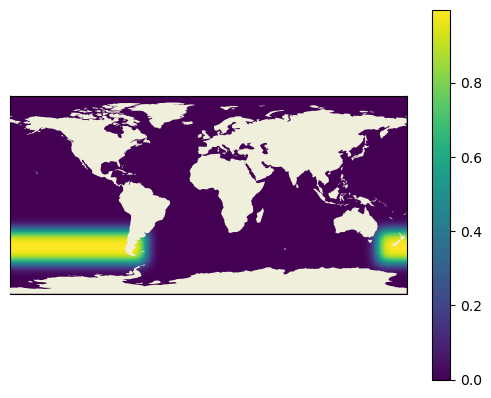

In [10]:
%%time

chunky = {'time':1, 'lat':320, 'lon':640}

# collect regular longitudes and latitudes
time = tas_1996['time'].values
lon_reg = tas_1996.coords['lon'].compute()
lat_reg = tas_1996.coords['lat'].compute()

proj = ccrs.PlateCarree()

# isolate the south Pacific between 170-320 E and 20-90 S
plon1 = 150.5; plon2 = 300.5
plat1 = -64.5; plat2 = -35.5

# make mask of longitudes and latitudes that we want
pac_lon_mask = (lon_reg > plon1) & (lon_reg < plon2)
pac_lat_mask = (lat_reg > plat1) & (lat_reg < plat2)
pac_mask = (pac_lon_mask * pac_lat_mask).astype(int)
# blur the edges to create the linear weighting
xdeg = 5
for i in range(10):
    pac_mask = pac_mask.rolling(lat=xdeg*2, center=True).mean().fillna(0.0)
    pac_mask = pac_mask.rolling(lon=xdeg*2, center=True).mean().fillna(0.0)
#runoff_pac_mask = pac_mask.expand_dims(time=runoff_swp['time'].values, axis=0).chunk(chunks=chunky)
pac_mask = pac_mask.expand_dims(time=time, axis=0).chunk(chunks=chunky).compute()

print(pac_mask.max().values, pac_mask.min().values)

plt.figure()
ax = plt.subplot(projection=proj)
plt.pcolormesh(lon_reg, lat_reg, pac_mask.isel(time=60).T, transform=ccrs.PlateCarree())
plt.colorbar()
ax.add_feature(cfeature.LAND, zorder=3)


/g/data/es60/pjb581/miniforge3/envs/model_assessment_env/lib/python3.10/site-packages/distributed/client.py:3370: UserWarning: Sending large graph of size 4.46 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


CPU times: user 20.8 s, sys: 14.1 s, total: 34.9 s
Wall time: 30.6 s


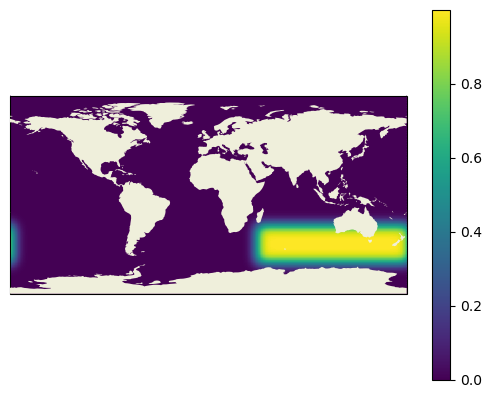

In [11]:
%%time

# isolate the south Indian between 60-180 E and 20-90 S
ilon1 = 40.5; ilon2 = 180.5
ilat1 = -64.5; ilat2 = -30.5

ind_lon_mask = (lon_reg > ilon1) & (lon_reg < ilon2)
ind_lat_mask = (lat_reg > ilat1) & (lat_reg < ilat2)
ind_mask = (ind_lon_mask * ind_lat_mask).astype(int)
# blur the edges to create the linear weighting
xdeg = 5
for i in range(10):
    ind_mask = ind_mask.rolling(lat=xdeg*2, center=True).mean().fillna(0.0)
    ind_mask = ind_mask.rolling(lon=xdeg*2, center=True).mean().fillna(0.0)
#runoff_ind_mask = ind_mask.expand_dims(time=runoff_swp['time'].values, axis=0).chunk(chunks=chunky)
ind_mask = ind_mask.expand_dims(time=time, axis=0).chunk(chunks=chunky).compute()

plt.figure()
ax = plt.subplot(projection=proj)
plt.pcolormesh(lon_reg, lat_reg, ind_mask.isel(time=60).T, transform=ccrs.PlateCarree())
plt.colorbar()
ax.add_feature(cfeature.LAND, zorder=3)


In [12]:
%%time

tas_1996 = tas_1996.assign_coords({'time':time}).compute()
tas_1997 = tas_1997.assign_coords({'time':time}).compute()
tas_1987 = tas_1987.assign_coords({'time':time}).compute()
tas_1988 = tas_1988.assign_coords({'time':time}).compute()

wnd_1996 = wnd_1996.assign_coords({'time':time}).compute()
wnd_1997 = wnd_1997.assign_coords({'time':time}).compute()
wnd_1987 = wnd_1987.assign_coords({'time':time}).compute()
wnd_1988 = wnd_1988.assign_coords({'time':time}).compute()



CPU times: user 29 s, sys: 6.79 s, total: 35.8 s
Wall time: 23.9 s


#### make the blend for the pacemaker experiments

In [13]:
%%time

# make the blend
tas_pac = ((tas_1996 + tas_1997) / 2).compute()
tas_sep_blend = (tas_1996 * pac_mask + tas_pac * (1-pac_mask)).compute()
tas_swp_blend = (tas_1997 * pac_mask + tas_pac * (1-pac_mask)).compute()
tas_ind = ((tas_1987 + tas_1988) / 2).compute()
tas_sei_blend = (tas_1987 * ind_mask + tas_ind * (1-ind_mask)).compute()
tas_swi_blend = (tas_1988 * ind_mask + tas_ind * (1-ind_mask)).compute()

wnd_pac = ((wnd_1996 + wnd_1997) / 2).compute()
wnd_sep_blend = (wnd_1996 * pac_mask + wnd_pac * (1-pac_mask)).compute()
wnd_swp_blend = (wnd_1997 * pac_mask + wnd_pac * (1-pac_mask)).compute()
wnd_ind = ((wnd_1987 + wnd_1988) / 2).compute()
wnd_sei_blend = (wnd_1987 * ind_mask + wnd_ind * (1-ind_mask)).compute()
wnd_swi_blend = (wnd_1988 * ind_mask + wnd_ind * (1-ind_mask)).compute()



CPU times: user 1min 59s, sys: 53 s, total: 2min 52s
Wall time: 1min 50s


### plot the slopes and the r2 contours

CPU times: user 1min 33s, sys: 27.3 s, total: 2min
Wall time: 1min 28s


Text(0.5, 1.2, 'Pacific')

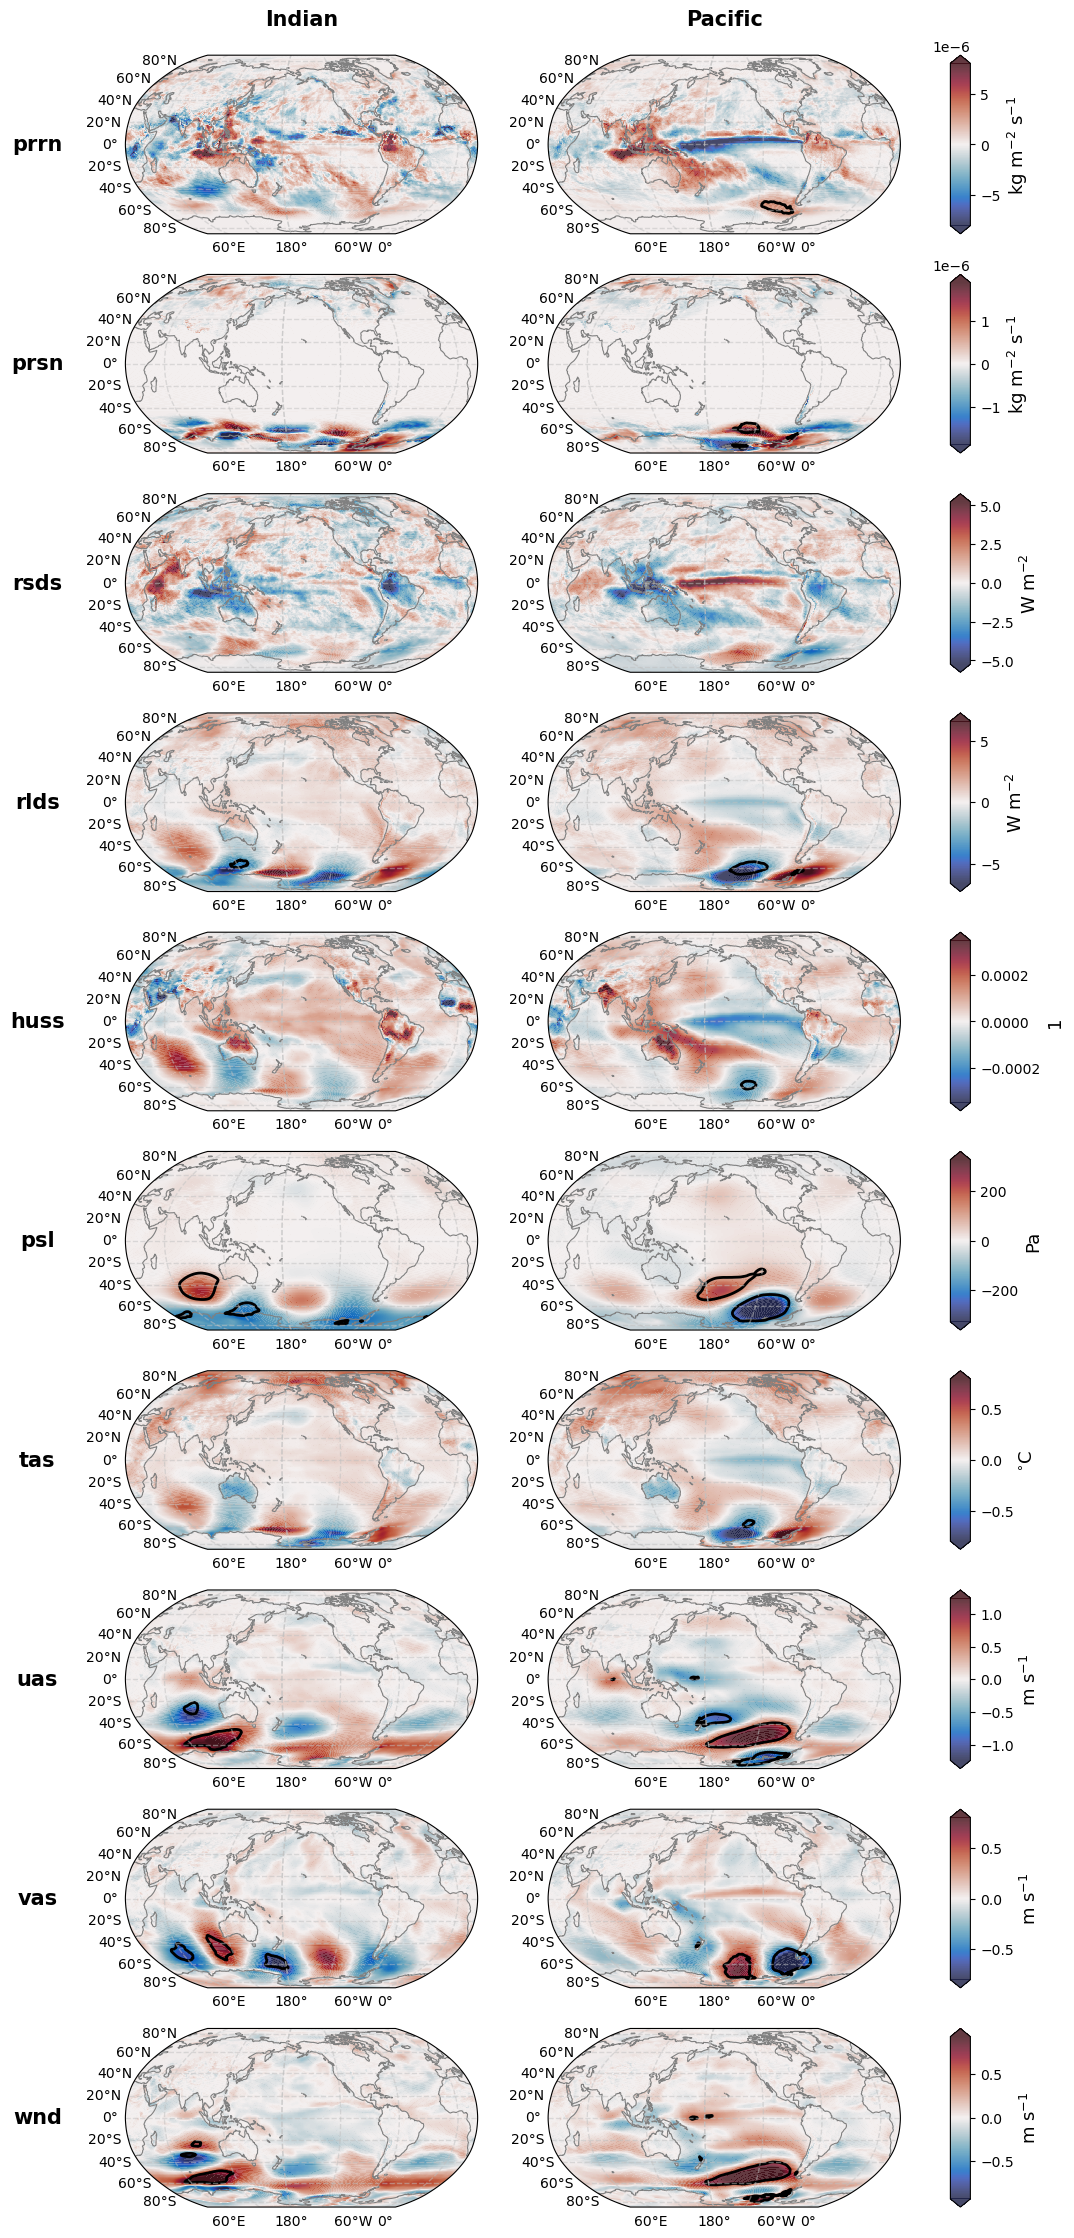

In [37]:
%%time

import matplotlib.ticker as mticker

fstic = 13
fslab = 15
proj = ccrs.Robinson(central_longitude=200.0)
colmap = lighten(cmo.balance, 0.8)

fig = plt.figure(figsize=(10,28))

gs = GridSpec(10,2)

lons = prra_ind_slope.coords['lon']
lats = prra_ind_slope.coords['lat']

ax = {}
pl = {}
ct = {}
gl = {}
cb = {}
slopes = [prra_ind_slope, prra_pac_slope,
          prsn_ind_slope, prsn_pac_slope,
          rsds_ind_slope, rsds_pac_slope,
          rlds_ind_slope, rlds_pac_slope,
          huss_ind_slope, huss_pac_slope,
          psl_ind_slope, psl_pac_slope,
          tas_ind_slope, tas_pac_slope,
          uas_ind_slope, uas_pac_slope,
          vas_ind_slope, vas_pac_slope,
          wnd_ind_slope, wnd_pac_slope]
pvalues = [prra_ind_p, prra_pac_p,
           prsn_ind_p, prsn_pac_p,
           rsds_ind_p, rsds_pac_p,
           rlds_ind_p, rlds_pac_p,
           huss_ind_p, huss_pac_p,
           psl_ind_p, psl_pac_p,
           tas_ind_p, tas_pac_p,
           uas_ind_p, uas_pac_p,
           vas_ind_p, vas_pac_p,
           wnd_ind_p, wnd_pac_p]
rvalues = [prra_ind_r, prra_pac_r,
           prsn_ind_r, prsn_pac_r,
           rsds_ind_r, rsds_pac_r,
           rlds_ind_r, rlds_pac_r,
           huss_ind_r, huss_pac_r,
           psl_ind_r, psl_pac_r,
           tas_ind_r, tas_pac_r,
           uas_ind_r, uas_pac_r,
           vas_ind_r, vas_pac_r,
           wnd_ind_r, wnd_pac_r]
labels = ['prrn', 'prsn', 'rsds', 'rlds', 'huss', 'psl', 'tas', 'uas', 'vas', 'wnd'] 

# plot
for ii in range(20):
    ax["ax%i"%(ii)] = plt.subplot(gs[ii], projection=proj)
    ax["ax%i"%(ii)].coastlines(linewidth=0.8, resolution="110m", color='grey')
    pl["pl%i"%(ii)] = ax["ax%i"%(ii)].pcolormesh(lons, lats, slopes[ii], cmap=colmap, vmin=-slopes[ii].std()*5, vmax=slopes[ii].std()*5, transform=ccrs.PlateCarree())
    #ct["ct%i"%(ii)] = ax["ax%i"%(ii)].contour(lons, lats, pvalues[ii], levels=[0.05], colors='k', linewidths=1, transform=ccrs.PlateCarree())
    ct["ct%i"%(ii)] = ax["ax%i"%(ii)].contour(lons, lats, rvalues[ii]**2, levels=[0.1], colors='k', linewidths=2, transform=ccrs.PlateCarree())
    gl["gl%i"%(ii)] = ax["ax%i"%(ii)].gridlines(draw_labels=True, linewidth=1.0, linestyle="--", alpha=0.5, color='silver')
    gl["gl%i"%(ii)].top_labels = False
    gl["gl%i"%(ii)].right_labels = False
    gl["gl%i"%(ii)].xlocator = mticker.FixedLocator([-180, -120, -60, 0, 60, 120, 180])
    gl["gl%i"%(ii)].ylocator = mticker.FixedLocator([-80, -60, -40, -20, 0, 20, 40, 60, 80])
    
for ix,ii in enumerate(np.arange(0,20,2)):
    plt.text(-0.25, 0.5, labels[ix], fontweight='bold', fontsize=fslab, ha='center', va='center', transform=ax["ax%i"%(ii)].transAxes)
    pos = ax["ax%i"%(ii+1)].get_position()
    cbax = fig.add_axes([pos.x1+0.05, pos.y0, 0.02, pos.y1 - pos.y0])
    cb["cb%i"%(ii+1)] = plt.colorbar(pl["pl%i"%(ii+1)], cax=cbax, orientation='vertical', extend='both')

cb["cb1"].ax.set_ylabel("kg m$^{-2}$ s$^{-1}$", fontsize=fstic)
cb["cb3"].ax.set_ylabel("kg m$^{-2}$ s$^{-1}$", fontsize=fstic)
cb["cb5"].ax.set_ylabel("W m$^{-2}$", fontsize=fstic)
cb["cb7"].ax.set_ylabel("W m$^{-2}$", fontsize=fstic)
cb["cb9"].ax.set_ylabel("1", fontsize=fstic)
cb["cb11"].ax.set_ylabel("Pa", fontsize=fstic)
cb["cb13"].ax.set_ylabel("$^{\circ}$C", fontsize=fstic)
cb["cb15"].ax.set_ylabel("m s$^{-1}$", fontsize=fstic)
cb["cb17"].ax.set_ylabel("m s$^{-1}$", fontsize=fstic)
cb["cb19"].ax.set_ylabel("m s$^{-1}$", fontsize=fstic)
    
plt.text(0.5, 1.2, "Indian", fontweight='bold', fontsize=fslab, ha='center', va='center', transform=ax["ax0"].transAxes)
plt.text(0.5, 1.2, "Pacific", fontweight='bold', fontsize=fslab, ha='center', va='center', transform=ax["ax1"].transAxes)



In [39]:
fig.savefig('/home/581/pjb581/analysis_samw/fig-linear_regression_Ipos_JRA55do.png', dpi=300, bbox_inches='tight')


### plot the tas and wnd for the main article

CPU times: user 19.1 s, sys: 5.69 s, total: 24.7 s
Wall time: 18.2 s


Text(0.5, 1.2, 'Pacific')

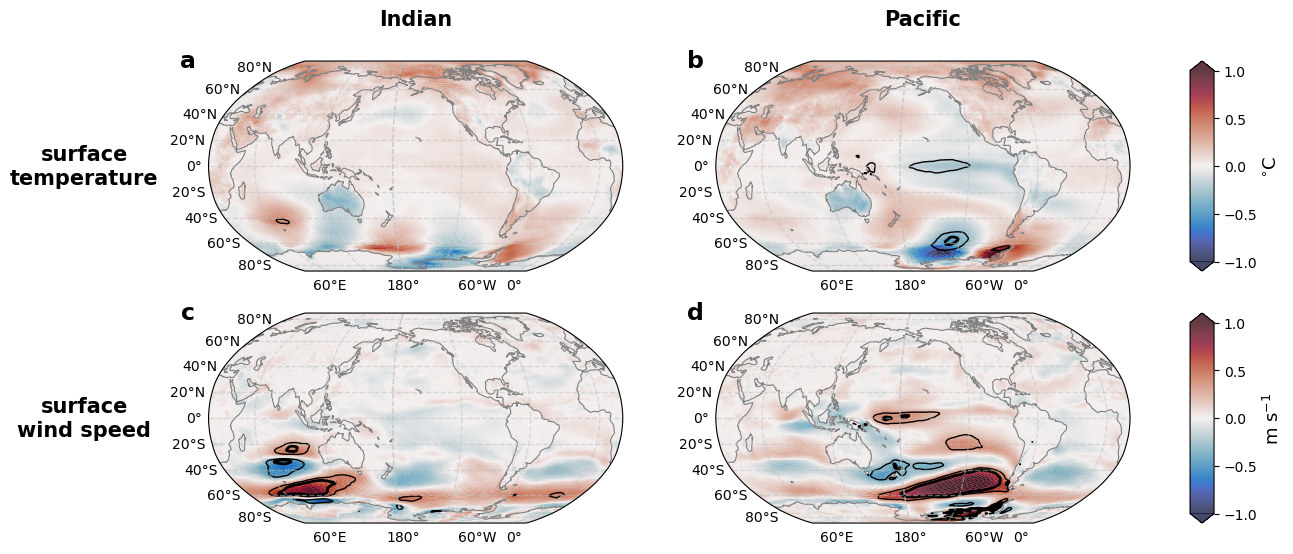

In [35]:
%%time

import matplotlib.ticker as mticker

fstic = 13
fslab = 15
proj = ccrs.Robinson(central_longitude=200.0)
colmap = lighten(cmo.balance, 0.8)

fig = plt.figure(figsize=(12,6))

gs = GridSpec(2,2)

lons = prra_ind_slope.coords['lon']
lats = prra_ind_slope.coords['lat']

ax = {}
pl = {}
ct = {}
gl = {}
cb = {}
slopes = [tas_ind_slope, tas_pac_slope,
          wnd_ind_slope, wnd_pac_slope]
pvalues = [tas_ind_p, tas_pac_p,
           wnd_ind_p, wnd_pac_p]
rvalues = [tas_ind_r, tas_pac_r,
           wnd_ind_r, wnd_pac_r]
labels = ['surface\ntemperature', 'surface\nwind speed'] 
vmins = [-1, -1, -1, -1]
vmaxs = [1, 1, 1, 1]
letters = ['a', 'b', 'c', 'd']

# plot
for ii in range(4):
    ax["ax%i"%(ii)] = plt.subplot(gs[ii], projection=proj)
    ax["ax%i"%(ii)].coastlines(linewidth=0.8, resolution="110m", color='grey')
    pl["pl%i"%(ii)] = ax["ax%i"%(ii)].pcolormesh(lons, lats, slopes[ii], cmap=colmap, vmin=vmins[ii], vmax=vmaxs[ii], transform=ccrs.PlateCarree())
    #ct["ct%i"%(ii)] = ax["ax%i"%(ii)].contour(lons, lats, pvalues[ii], levels=[0.05], colors='k', linewidths=1, transform=ccrs.PlateCarree())
    ct["ct%i"%(ii)] = ax["ax%i"%(ii)].contour(lons, lats, rvalues[ii]**2, levels=[0.05], colors='k', linewidths=1, transform=ccrs.PlateCarree())
    ct["ct%i"%(ii)] = ax["ax%i"%(ii)].contour(lons, lats, rvalues[ii]**2, levels=[0.10], colors='k', linewidths=2, transform=ccrs.PlateCarree())
    gl["gl%i"%(ii)] = ax["ax%i"%(ii)].gridlines(draw_labels=True, linewidth=1.0, linestyle="--", alpha=0.5, color='silver')
    gl["gl%i"%(ii)].top_labels = False
    gl["gl%i"%(ii)].right_labels = False
    gl["gl%i"%(ii)].xlocator = mticker.FixedLocator([-180, -120, -60, 0, 60, 120, 180])
    gl["gl%i"%(ii)].ylocator = mticker.FixedLocator([-80, -60, -40, -20, 0, 20, 40, 60, 80])
    plt.text(-0.05,1.0, letters[ii], fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax["ax%i"%(ii)].transAxes)
    
for ix,ii in enumerate(np.arange(0,4,2)):
    plt.text(-0.3, 0.5, labels[ix], fontweight='bold', fontsize=fslab, ha='center', va='center', transform=ax["ax%i"%(ii)].transAxes)
    pos = ax["ax%i"%(ii+1)].get_position()
    cbax = fig.add_axes([pos.x1+0.05, pos.y0, 0.02, pos.y1 - pos.y0])
    cb["cb%i"%(ii+1)] = plt.colorbar(pl["pl%i"%(ii+1)], cax=cbax, orientation='vertical', extend='both')

cb["cb1"].ax.set_ylabel("$^{\circ}$C", fontsize=fstic)
cb["cb3"].ax.set_ylabel("m s$^{-1}$", fontsize=fstic)
    
plt.text(0.5, 1.2, "Indian", fontweight='bold', fontsize=fslab, ha='center', va='center', transform=ax["ax0"].transAxes)
plt.text(0.5, 1.2, "Pacific", fontweight='bold', fontsize=fslab, ha='center', va='center', transform=ax["ax1"].transAxes)


In [36]:
fig.savefig('/home/581/pjb581/analysis_samw/fig-linear_regression_Ipos_JRA55do_tas_wnd.png', dpi=300, bbox_inches='tight')


CPU times: user 1min 10s, sys: 14.7 s, total: 1min 25s
Wall time: 59.9 s


Text(0.5, 1.3, 'Pacific\n(1996 minus 1987)\n(+ minus - I$_{MLD}$ conditions)')

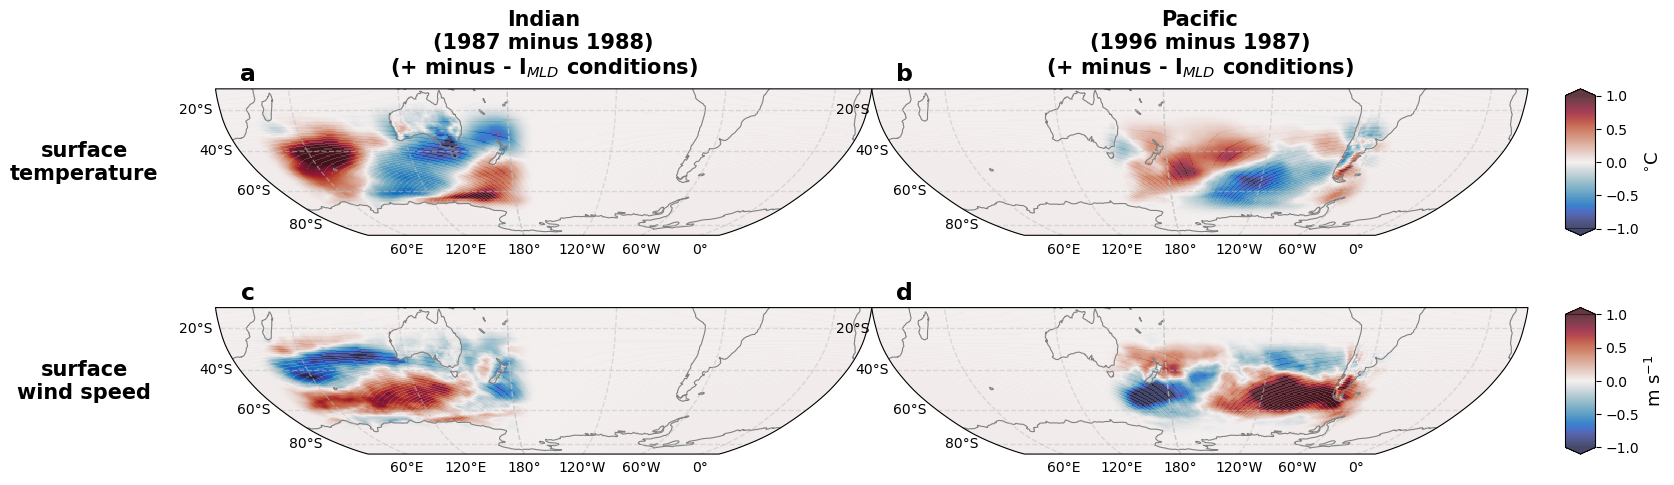

In [24]:
%%time

import matplotlib.ticker as mticker

fstic = 13
fslab = 15
proj = ccrs.Robinson(central_longitude=200.0)
colmap = lighten(cmo.balance, 0.8)

fig = plt.figure(figsize=(15,5))

gs = GridSpec(2,2)

lons = tas_1997.coords['lon'].values
lats = tas_1997.coords['lat'].values

ax = {}
pl = {}
ct = {}
gl = {}
cb = {}
slopes = [(tas_sei_blend-tas_swi_blend).mean(dim='time'), (tas_sep_blend-tas_swp_blend).mean(dim='time'),
          (wnd_sei_blend-wnd_swi_blend).mean(dim='time'), (wnd_sep_blend-wnd_swp_blend).mean(dim='time')]
labels = ['surface\ntemperature', 'surface\nwind speed'] 
vmins = [-1, -1, -1, -1]
vmaxs = [1, 1, 1, 1]
letters = ['a', 'b', 'c', 'd']

# plot
for ii in range(4):
    ax["ax%i"%(ii)] = plt.subplot(gs[ii], projection=proj)
    ax["ax%i"%(ii)].coastlines(linewidth=0.8, resolution="110m", color='grey')
    pl["pl%i"%(ii)] = ax["ax%i"%(ii)].pcolormesh(lons, lats, slopes[ii], cmap=colmap, vmin=vmins[ii], vmax=vmaxs[ii], transform=ccrs.PlateCarree())
    #ct["ct%i"%(ii)] = ax["ax%i"%(ii)].contour(lons, lats, pvalues[ii], levels=[0.05], colors='k', linewidths=1, transform=ccrs.PlateCarree())
    #ct["ct%i"%(ii)] = ax["ax%i"%(ii)].contour(lons, lats, rvalues[ii]**2, levels=[0.05], colors='k', linewidths=1, transform=ccrs.PlateCarree())
    #ct["ct%i"%(ii)] = ax["ax%i"%(ii)].contour(lons, lats, rvalues[ii]**2, levels=[0.10], colors='k', linewidths=2, transform=ccrs.PlateCarree())
    gl["gl%i"%(ii)] = ax["ax%i"%(ii)].gridlines(draw_labels=True, linewidth=1.0, linestyle="--", alpha=0.5, color='silver')
    gl["gl%i"%(ii)].top_labels = False
    gl["gl%i"%(ii)].right_labels = False
    gl["gl%i"%(ii)].xlocator = mticker.FixedLocator([-180, -120, -60, 0, 60, 120, 180])
    gl["gl%i"%(ii)].ylocator = mticker.FixedLocator([-80, -60, -40, -20, 0, 20, 40, 60, 80])
    plt.text(0.05,1.10, letters[ii], fontweight='bold', fontsize=fslab+2, ha='center', va='center', transform=ax["ax%i"%(ii)].transAxes)
    ax["ax%i"%(ii)].set_extent([-180,180,-90,-10], crs=ccrs.PlateCarree())

plt.subplots_adjust(top=0.925, bottom=0.05, left=0.075, right=0.95, hspace=0.0, wspace=0.0)

for ix,ii in enumerate(np.arange(0,4,2)):
    plt.text(-0.2, 0.5, labels[ix], fontweight='bold', fontsize=fslab, ha='center', va='center', transform=ax["ax%i"%(ii)].transAxes)
    pos = ax["ax%i"%(ii+1)].get_position()
    cbax = fig.add_axes([pos.x1+0.025, pos.y0, 0.02, pos.y1 - pos.y0])
    cb["cb%i"%(ii+1)] = plt.colorbar(pl["pl%i"%(ii+1)], cax=cbax, orientation='vertical', extend='both')

cb["cb1"].ax.set_ylabel("$^{\circ}$C", fontsize=fstic)
cb["cb3"].ax.set_ylabel("m s$^{-1}$", fontsize=fstic)

plt.text(0.5, 1.3, "Indian\n(1987 minus 1988)\n(+ minus - I$_{MLD}$ conditions)", fontweight='bold', fontsize=fslab, ha='center', va='center', transform=ax["ax0"].transAxes)
plt.text(0.5, 1.3, "Pacific\n(1996 minus 1987)\n(+ minus - I$_{MLD}$ conditions)", fontweight='bold', fontsize=fslab, ha='center', va='center', transform=ax["ax1"].transAxes)



In [17]:
fig.savefig('/home/581/pjb581/analysis_samw/fig-pacemakerforcings_Ipos_JRA55do_tas_wnd.png', dpi=300, bbox_inches='tight')
